In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load engineered ML features
X_features = np.load("../data/processed/ml_features_400.npy")

# Load labels (for reference)
data = np.load("../data/processed/processed_400_timesteps.npz", allow_pickle=True)
y = data["y"]

print("Feature shape:", X_features.shape)


Feature shape: (10000, 1200)


In [4]:
from tensorflow.keras.models import load_model

mil_model = load_model("../outputs/models/mil_attention_model")


In [5]:
def risk_level(prob):
    if prob >= 0.8:
        return "VERY HIGH"
    elif prob >= 0.6:
        return "HIGH"
    elif prob >= 0.4:
        return "MODERATE"
    else:
        return "LOW"


In [6]:
def simulate_real_time(model, X, step=1, samples=10):
    """
    Simulates real-time solar flare forecasting.
    """
    for i in range(0, samples, step):
        sample = X[i:i+1]   # incoming observation
        probs = model.predict(sample)[0]
        max_prob = np.max(probs)

        print(f"⏱ Time step {i}")
        print(f"Flare risk probability: {max_prob:.2f}")
        print(f"Risk level: {risk_level(max_prob)}")
        print("-" * 40)


In [7]:
def create_mil_instances(X, segments=8):
    instance_size = X.shape[1] // segments
    bags = []

    for i in range(X.shape[0]):
        bag = []
        for s in range(segments):
            start = s * instance_size
            end = (s + 1) * instance_size
            bag.append(X[i, start:end])
        bags.append(bag)

    return np.array(bags)


In [8]:
X_bags = create_mil_instances(X_features, segments=8)

print("MIL bag shape:", X_bags.shape)


MIL bag shape: (10000, 8, 150)


In [9]:
simulate_real_time(mil_model, X_bags, samples=20)


1/1 [==============================] - 0s 475ms/step
⏱ Time step 0
Flare risk probability: 0.99
Risk level: VERY HIGH
----------------------------------------
1/1 [==============================] - 0s 42ms/step
⏱ Time step 1
Flare risk probability: 0.95
Risk level: VERY HIGH
----------------------------------------
1/1 [==============================] - 0s 49ms/step
⏱ Time step 2
Flare risk probability: 0.97
Risk level: VERY HIGH
----------------------------------------
1/1 [==============================] - 0s 46ms/step
⏱ Time step 3
Flare risk probability: 0.94
Risk level: VERY HIGH
----------------------------------------
1/1 [==============================] - 0s 34ms/step
⏱ Time step 4
Flare risk probability: 0.99
Risk level: VERY HIGH
----------------------------------------
1/1 [==============================] - 0s 38ms/step
⏱ Time step 5
Flare risk probability: 0.95
Risk level: VERY HIGH
----------------------------------------
1/1 [==============================] - 0s 29ms/step

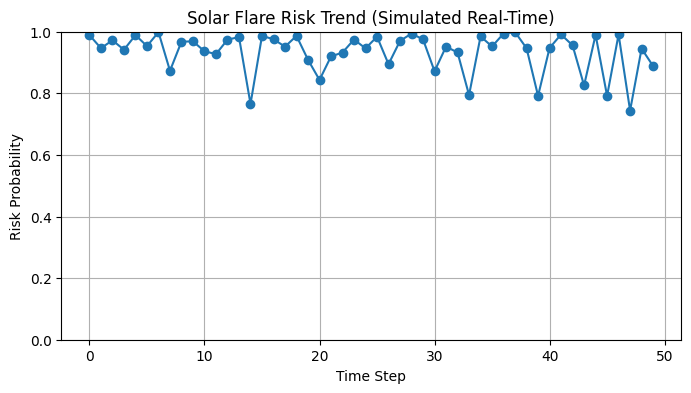

In [10]:
risk_scores = []

for i in range(50):
    probs = mil_model.predict(X_bags[i:i+1], verbose=0)[0]
    risk_scores.append(np.max(probs))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(risk_scores, marker="o")
plt.title("Solar Flare Risk Trend (Simulated Real-Time)")
plt.xlabel("Time Step")
plt.ylabel("Risk Probability")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


In [11]:
import numpy as np

X_features = np.load("../data/processed/ml_features_400.npy")

def create_mil_instances(X, segments=8):
    instance_size = X.shape[1] // segments
    bags = []
    for i in range(X.shape[0]):
        bag = []
        for s in range(segments):
            start = s * instance_size
            end = (s + 1) * instance_size
            bag.append(X[i, start:end])
        bags.append(bag)
    return np.array(bags)

X_bags = create_mil_instances(X_features, segments=8)

print("X_bags shape:", X_bags.shape)


X_bags shape: (10000, 8, 150)
